# Zadanie 1. Regresja - głębokość vs. szerokość sieci

---

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from torch.utils.data import DataLoader

In [2]:
# physiochemical_protein
p_p = fetch_openml(data_id=42903, as_frame=True)


In [3]:
p_p.data.columns

Index(['RMSD', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9'], dtype='object')

In [4]:
X = p_p.data[p_p.data.columns[1:]]
y = p_p.data.RMSD

In [8]:
X

,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102.0,27.0302
1,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39.0,38.5468
2,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29.0,38.8119
3,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70.0,39.0651
4,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41.0,39.9147
...,...,...,...,...,...,...,...,...,...
45725,8037.12,2777.68,0.34560,64.3390,1.105797e+06,112.7460,3384.21,84.0,36.8036
45726,7978.76,2508.57,0.31440,75.8654,1.116725e+06,102.2770,3974.52,54.0,36.0470
45727,7726.65,2489.58,0.32220,70.9903,1.076560e+06,103.6780,3290.46,46.0,37.4718
45728,8878.93,3055.78,0.34416,94.0314,1.242266e+06,115.1950,3421.79,41.0,35.6045


In [9]:
X.shape

(45730, 9)

In [5]:
X_train, X_testval, y_train, y_testval = train_test_split(X,y,test_size=.40)

# 40% * 45 730 = 18 292
y_testval.size

18292

In [6]:
X_test, X_val, y_test, y_val = train_test_split(X_testval,y_testval, train_size=0.5)

# 50% * 18 292 = 9 146 
y_test.size

9146

In [12]:
class MLP_Const_Width(nn.Module):
    def __init__(self, n_hidden, hidden_dim=64):
        super().__init__()

        self.input = nn.Linear(9, hidden_dim)
        self.layers = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)]
        )
        self.output = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()

    def forward(self,X):
        X = self.relu(self.input(X))

        for layer in self.layers:
            X = self.relu(layer(X))

        X = self.output(X)
        
        return X

In [13]:
class MLP_Const_Depth(nn.Module):
    def __init__(self, hidden_dim, n_hidden=2):
        super().__init__()

        self.input = nn.Linear(9, hidden_dim[0][0])
        self.layers = nn.ModuleList(
            [nn.Linear(hidden_dim[i][0], hidden_dim[i][1]) for i in range(n_hidden)]
        )
        self.output = nn.Linear(hidden_dim[-1][1], 1)
        self.relu = nn.ReLU()

    def forward(self,X):
        X = self.relu(self.input(X))

        for layer in self.layers:
            X = self.relu(layer(X))

        X = self.output(X)
        
        return X

In [7]:
LEARNING_RATE = 0.01
BATCH_SIZE = 128
N_EPOCHS = 100
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
loss_fn = nn.MSELoss()

In [8]:
class ProteinDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        self.X = torch.tensor(X_scaled, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)
        
        # Notka
        # Nie przesyłaj całego tensora .to(DEVICE),
        # Zamiast tego wykonaj to na batchu w pętli

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [9]:
train_loader = DataLoader(ProteinDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ProteinDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(ProteinDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

## Stała szerokość

In [30]:
for n_hidden in [1,2,4]:
    model_const_width = MLP_Const_Width(n_hidden=n_hidden, hidden_dim=64).to(DEVICE)

    optimizer = optim.Adam(model_const_width.parameters(), lr=LEARNING_RATE)
    train_losses = []
    val_losses = []

    best_val_loss = float('inf')

    for epoch in range(N_EPOCHS):
        model_const_width.train()

        train_loss = 0.0
        for X_train_batch, y_train_batch in train_loader:
            X_train_batch, y_train_batch = X_train_batch.to(DEVICE), y_train_batch.to(DEVICE)

            optimizer.zero_grad()
            pred_batch = model_const_width(X_train_batch)
            loss_batch = loss_fn(pred_batch, y_train_batch)
            loss_batch.backward()
            train_loss += loss_batch.item()
            optimizer.step()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        with torch.inference_mode():
            model_const_width.eval()

            val_loss = 0.0
            for X_val_batch, y_val_batch in val_loader:
                X_val_batch, y_val_batch = X_val_batch.to(DEVICE), y_val_batch.to(DEVICE)
                
                pred_val = model_const_width(X_val_batch)
                val_loss += loss_fn(pred_val, y_val_batch).item()
            
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss

            dct = {
                'model_state': model_const_width.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'epoch': epoch,
                'best_val_loss': best_val_loss,
                'train_losses': train_losses,
                'val_losses': val_losses
            }

            torch.save(dct, f'model_const_width_{n_hidden}_hidden.pth')
                
        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            

    

Epoch 0 | Loss: 29.1470 | Val Loss: 25.1635
Epoch 10 | Loss: 20.3245 | Val Loss: 20.1441
Epoch 20 | Loss: 18.5507 | Val Loss: 18.8272
Epoch 30 | Loss: 17.2832 | Val Loss: 18.2430
Epoch 40 | Loss: 16.2208 | Val Loss: 17.1067
Epoch 50 | Loss: 15.3461 | Val Loss: 16.5602
Epoch 60 | Loss: 14.8316 | Val Loss: 16.3783
Epoch 70 | Loss: 14.3440 | Val Loss: 16.3785
Epoch 80 | Loss: 14.0943 | Val Loss: 16.4488
Epoch 90 | Loss: 13.7901 | Val Loss: 16.1303
Epoch 0 | Loss: 29.4308 | Val Loss: 25.0988
Epoch 10 | Loss: 19.8674 | Val Loss: 20.7357
Epoch 20 | Loss: 17.6678 | Val Loss: 18.1895
Epoch 30 | Loss: 15.9053 | Val Loss: 16.9906
Epoch 40 | Loss: 14.8077 | Val Loss: 16.6218
Epoch 50 | Loss: 14.1242 | Val Loss: 16.6803
Epoch 60 | Loss: 13.3654 | Val Loss: 16.2218
Epoch 70 | Loss: 12.8952 | Val Loss: 16.0482
Epoch 80 | Loss: 13.2814 | Val Loss: 16.3877
Epoch 90 | Loss: 12.0487 | Val Loss: 15.4720
Epoch 0 | Loss: 29.5969 | Val Loss: 26.4470
Epoch 10 | Loss: 19.4433 | Val Loss: 19.7942
Epoch 20 | Lo

## Stała głębokość

In [31]:
for hidden_dim in [[(128, 64), (64, 32)], [(256, 128), (128, 64)]]:
    model_const_width = MLP_Const_Depth(hidden_dim=hidden_dim).to(DEVICE)

    optimizer = optim.Adam(model_const_width.parameters(), lr=LEARNING_RATE)
    train_losses = []
    val_losses = []

    best_val_loss = float('inf')

    for epoch in range(N_EPOCHS):
        model_const_width.train()

        train_loss = 0.0
        for X_train_batch, y_train_batch in train_loader:
            X_train_batch, y_train_batch = X_train_batch.to(DEVICE), y_train_batch.to(DEVICE)

            optimizer.zero_grad()
            pred_batch = model_const_width(X_train_batch)
            loss_batch = loss_fn(pred_batch, y_train_batch)
            loss_batch.backward()
            train_loss += loss_batch.item()
            optimizer.step()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        with torch.inference_mode():
            model_const_width.eval()

            val_loss = 0.0
            for X_val_batch, y_val_batch in val_loader:
                X_val_batch, y_val_batch = X_val_batch.to(DEVICE), y_val_batch.to(DEVICE)
                
                pred_val = model_const_width(X_val_batch)
                val_loss += loss_fn(pred_val, y_val_batch).item()
            
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss

            dct = {
                'model_state': model_const_width.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'epoch': epoch,
                'best_val_loss': best_val_loss,
                'train_losses': train_losses,
                'val_losses': val_losses
            }

            torch.save(dct, f'model_const_depth_{hidden_dim}.pth')
                
        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            

    

Epoch 0 | Loss: 28.9545 | Val Loss: 25.5341
Epoch 10 | Loss: 19.2950 | Val Loss: 21.2015
Epoch 20 | Loss: 17.4405 | Val Loss: 18.2641
Epoch 30 | Loss: 16.1160 | Val Loss: 16.9043
Epoch 40 | Loss: 15.0978 | Val Loss: 16.4061
Epoch 50 | Loss: 14.4354 | Val Loss: 16.5110
Epoch 60 | Loss: 13.9714 | Val Loss: 16.5122
Epoch 70 | Loss: 13.3733 | Val Loss: 16.1241
Epoch 80 | Loss: 13.0479 | Val Loss: 15.9042
Epoch 90 | Loss: 12.6813 | Val Loss: 16.2436
Epoch 0 | Loss: 27.4444 | Val Loss: 23.7242
Epoch 10 | Loss: 19.1972 | Val Loss: 20.0557
Epoch 20 | Loss: 16.4739 | Val Loss: 17.2067
Epoch 30 | Loss: 14.9304 | Val Loss: 17.2710
Epoch 40 | Loss: 13.6616 | Val Loss: 15.7408
Epoch 50 | Loss: 12.5507 | Val Loss: 15.3140
Epoch 60 | Loss: 11.7873 | Val Loss: 15.5457
Epoch 70 | Loss: 11.2587 | Val Loss: 16.3549
Epoch 80 | Loss: 10.4912 | Val Loss: 15.8875
Epoch 90 | Loss: 10.0605 | Val Loss: 15.5061


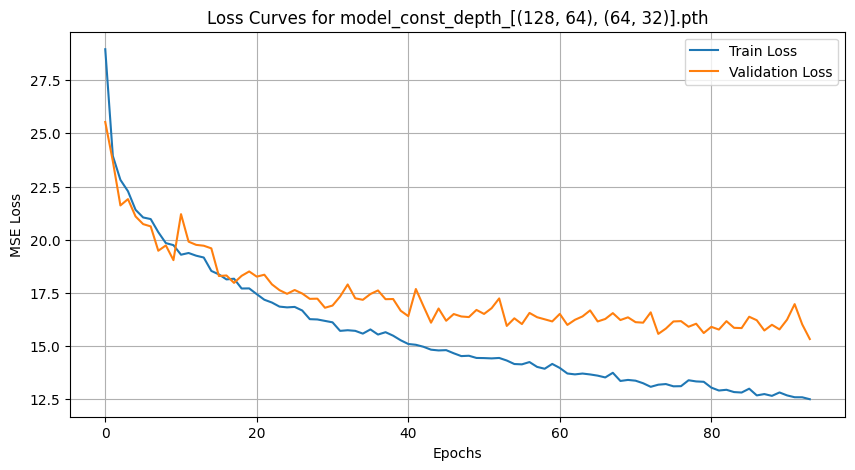

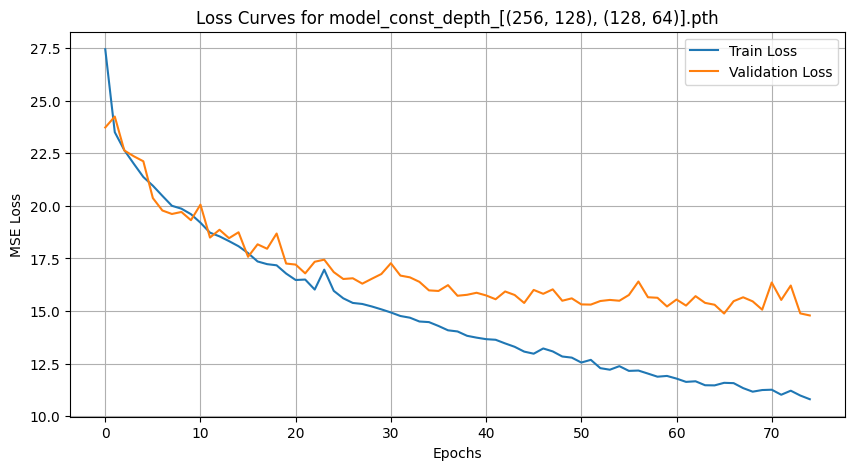

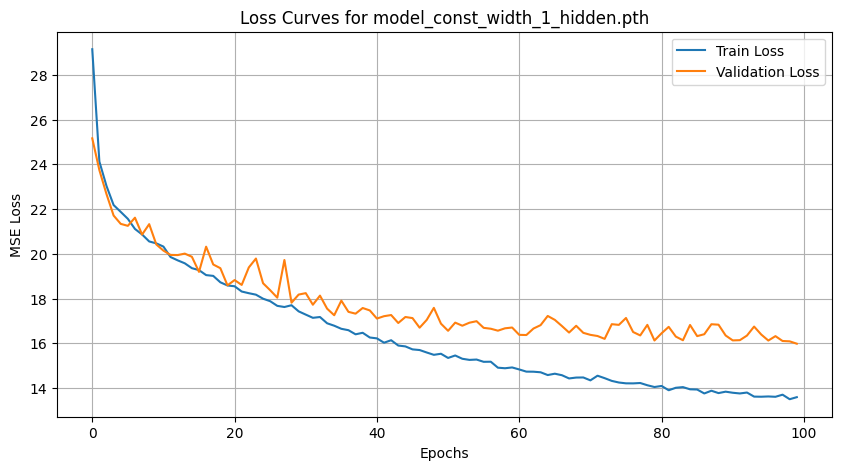

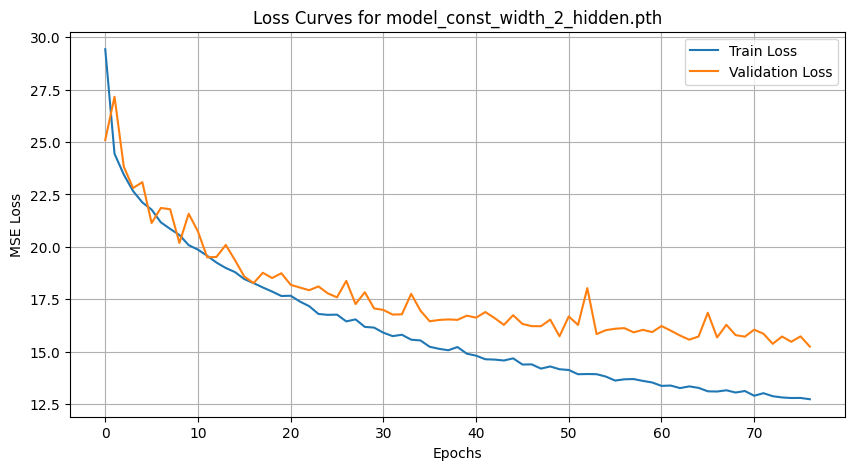

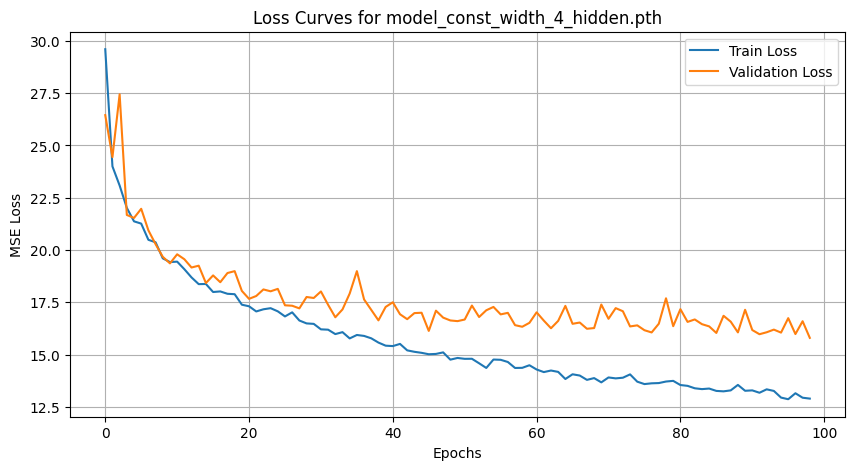

In [33]:
import matplotlib.pyplot as plt
import os

def plot_losses(model_name):
    checkpoint = torch.load(f'{model_name}')
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(f'Loss Curves for {model_name}')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid()
    plt.show()

for filename in os.listdir():
    if filename.startswith('model_const_width') or filename.startswith('model_const_depth') and filename.endswith('.pth'):
        plot_losses(filename)

## Tests

In [36]:
def evaluate_model(model_name):
    checkpoint = torch.load(f'{model_name}')
    model_state = checkpoint['model_state']
    model_name = model_name.split('.')[0]

    if 'const_width' in model_name:
        n_hidden = int(model_name.split('_')[3])
        model = MLP_Const_Width(n_hidden=n_hidden, hidden_dim=64).to(DEVICE)
    else:
        hidden_dim_str = model_name.split('_')[3]
        hidden_dim = eval(hidden_dim_str)
        model = MLP_Const_Depth(hidden_dim=hidden_dim).to(DEVICE)

    model.load_state_dict(model_state)
    model.eval()

    test_loss = 0.0
    with torch.inference_mode():
        for X_test_batch, y_test_batch in test_loader:
            X_test_batch, y_test_batch = X_test_batch.to(DEVICE), y_test_batch.to(DEVICE)
            pred_test = model(X_test_batch)
            test_loss += loss_fn(pred_test, y_test_batch).item()
    
    test_loss /= len(test_loader)
    print(f"Test Loss for {model_name}: {test_loss:.4f}")

for filename in os.listdir():
    if filename.startswith('model_const_width') or filename.startswith('model_const_depth') and filename.endswith('.pth'):
        evaluate_model(filename)

Test Loss for model_const_depth_[(128, 64), (64, 32)]: 15.4348
Test Loss for model_const_depth_[(256, 128), (128, 64)]: 15.7459
Test Loss for model_const_width_1_hidden: 16.1516
Test Loss for model_const_width_2_hidden: 15.2532
Test Loss for model_const_width_4_hidden: 15.9788


---

# Zadanie 2. Regresja - optymalizacja sieci

---

In [10]:
import optuna
from sklearn.model_selection import KFold
from tqdm import tqdm

c:\Users\posze\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
class MLP_Optuna(nn.Module):
    def __init__(self, hidden_dims, n_hidden):
        super().__init__()
        self.input = nn.Linear(9, hidden_dims[0])

        self.layers = nn.ModuleList(
            [nn.Linear(hidden_dims[i], hidden_dims[i+1]) for i in range(n_hidden)]
        )

        self.output = nn.Linear(hidden_dims[-1], 1)
        self.relu = nn.ReLU()

    def forward(self,X):
        X = self.relu(self.input(X))

        for layer in self.layers:
            X = self.relu(layer(X))

        X = self.output(X)
        
        return X

In [12]:
def create_best_models(train_val_dataset):
    kFold = KFold(n_splits=5, shuffle=True)

    for fold, (train_idx, val_idx) in enumerate(tqdm(kFold.split(train_val_dataset))):
        train_subset = torch.utils.data.Subset(train_val_dataset, train_idx)
        val_subset = torch.utils.data.Subset(train_val_dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
        
        def objective(trial: optuna.Trial):
            n_hidden = trial.suggest_int('n_hidden', 1, 4)
            
            hidden_dims = []

            for i in range(n_hidden + 1):
                dim = trial.suggest_categorical(f'hidden_dim_{i}', [32, 64, 128, 256])
                hidden_dims.append(dim)
                
            model = MLP_Optuna(hidden_dims=hidden_dims, n_hidden=n_hidden).to(DEVICE)
            optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
            loss_fn = nn.MSELoss()
            train_losses = []
            val_losses = []
            best_val_loss = float('inf')

            for epoch in range(N_EPOCHS):
                model.train()
                train_loss = 0.0

                for X_train_batch, y_train_batch in train_loader:
                    X_train_batch, y_train_batch = X_train_batch.to(DEVICE), y_train_batch.to(DEVICE)

                    optimizer.zero_grad()
                    pred_batch = model(X_train_batch)
                    loss_batch = loss_fn(pred_batch, y_train_batch)
                    loss_batch.backward()
                    train_loss += loss_batch.item()
                    optimizer.step()
                
                train_loss /= len(train_loader)

                model.eval()
                val_loss = 0.0

                with torch.inference_mode():
                    for X_val_batch, y_val_batch in val_loader:
                        X_val_batch, y_val_batch = X_val_batch.to(DEVICE), y_val_batch.to(DEVICE)
                        pred_val = model(X_val_batch)
                        val_loss += loss_fn(pred_val, y_val_batch).item()
                
                val_loss /= len(val_loader)

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    
                    dic = {
                        'model_state': model.state_dict(),
                        'optimizer_state': optimizer.state_dict(),
                        'epoch': epoch,
                        'best_val_loss': best_val_loss,
                        'train_losses': train_losses,
                        'val_losses': val_losses,
                        'hyperparameters': {
                            'n_hidden': n_hidden,
                            'hidden_dims': hidden_dims
                        }
                    }

                    torch.save(dic, f'optuna_model_fold_{fold}.pth')

            return train_loss + val_loss

        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=20)

In [13]:
from torch.utils.data import ConcatDataset

train_val_dataset = ConcatDataset([train_loader.dataset, val_loader.dataset])
train_val_dataset.targets = torch.cat([train_loader.dataset.y, val_loader.dataset.y], dim=0)


In [14]:
create_best_models(train_val_dataset)

0it [00:00, ?it/s][I 2026-04-10 07:02:40,598] A new study created in memory with name: no-name-d54ca8bd-de59-43ae-9c6a-b77ce69b411a
[I 2026-04-10 07:07:12,043] Trial 0 finished with value: 29.051798267404713 and parameters: {'n_hidden': 3, 'hidden_dim_0': 256, 'hidden_dim_1': 32, 'hidden_dim_2': 32, 'hidden_dim_3': 32}. Best is trial 0 with value: 29.051798267404713.
[I 2026-04-10 07:08:54,039] Trial 1 finished with value: 25.407949729167523 and parameters: {'n_hidden': 4, 'hidden_dim_0': 128, 'hidden_dim_1': 128, 'hidden_dim_2': 256, 'hidden_dim_3': 128, 'hidden_dim_4': 256}. Best is trial 1 with value: 25.407949729167523.
[I 2026-04-10 07:10:43,770] Trial 2 finished with value: 29.118899726451225 and parameters: {'n_hidden': 4, 'hidden_dim_0': 32, 'hidden_dim_1': 64, 'hidden_dim_2': 64, 'hidden_dim_3': 128, 'hidden_dim_4': 64}. Best is trial 1 with value: 25.407949729167523.
[I 2026-04-10 07:12:33,517] Trial 3 finished with value: 29.084535989214224 and parameters: {'n_hidden': 4, 'h

In [15]:
def mean_voting(models, test_loader):
    final_predictions = torch.zeros((len(test_loader.dataset)))
    
    predictions = torch.zeros((len(test_loader.dataset), len(models)))
    for idx,model in enumerate(models):
        model.eval()
        model_predictions = []

        with torch.inference_mode():
            for X_test_batch, y_test_batch in test_loader:
                X_test_batch = X_test_batch.to(DEVICE)
                pred = model(X_test_batch)
                model_predictions.append(pred.cpu())
        
        predictions[:, idx] = torch.cat(model_predictions,dim=0).squeeze()
    final_predictions = predictions.mean(axis=1)

    return final_predictions

In [17]:
import os

In [18]:
models_names = [filename for filename in os.listdir() if filename.startswith('optuna') and filename.endswith('.pth')]

models = []

for models_name in models_names:
    checkpoint = torch.load(models_name)
    model_state = checkpoint['model_state']
    model_name = models_name.split('.')[0]

    hyperparameters = checkpoint['hyperparameters']
    n_hidden = hyperparameters['n_hidden']
    hidden_dims = hyperparameters['hidden_dims']

    model = MLP_Optuna(hidden_dims=hidden_dims, n_hidden=n_hidden).to(DEVICE)
    model.load_state_dict(model_state)    
    
    models.append(model)

In [19]:
predictions = mean_voting(models, test_loader)

In [31]:
def evaluate_optuna_models(preds, test_loader):
    loss = 0.0
    preds = preds.to(DEVICE)

    for idx, (_, y_test_batch) in enumerate(test_loader):
        start_idx = idx * test_loader.batch_size
        end_idx = start_idx + len(y_test_batch)
        y_test_batch = y_test_batch.squeeze()

        batch_preds = preds[start_idx:end_idx].to(DEVICE)
        y_test_batch = y_test_batch.to(DEVICE)

        loss += loss_fn(batch_preds, y_test_batch).item()

    final_loss = loss / len(test_loader)

    print(f"Mean Voting Test Loss: {final_loss:.4f}")
evaluate_optuna_models(predictions, test_loader)

Mean Voting Test Loss: 13.1072


---